# Customer Churn Prediction

## Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve)
import joblib

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.shape

(7043, 21)

## Exploratory Data Analysis

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn rate: 26.5%


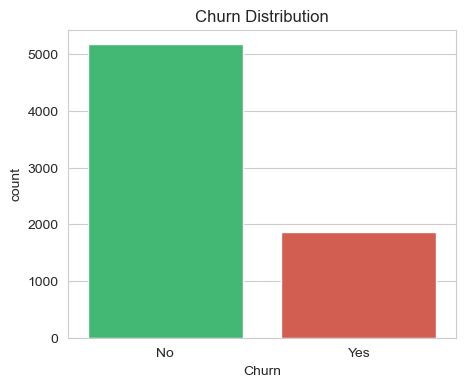

In [3]:
churn_counts = df['Churn'].value_counts()
print(churn_counts)
print(f"Churn rate: {(churn_counts['Yes']/len(df))*100:.1f}%")

plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Churn', hue='Churn', palette=['#2ecc71','#e74c3c'], legend=False)
plt.title('Churn Distribution')
plt.show()

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df[df['TotalCharges'].isnull()][['tenure','MonthlyCharges','TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


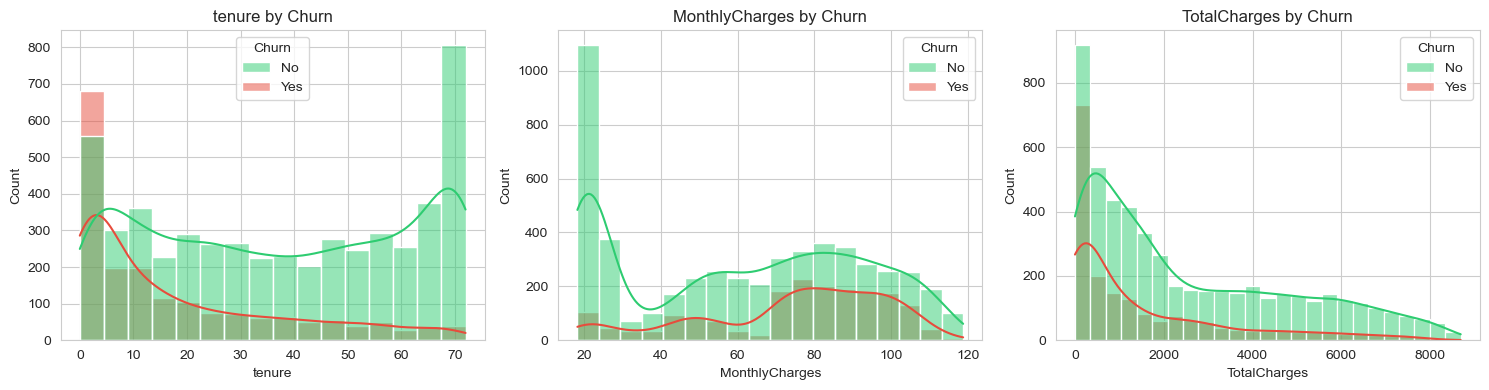

In [5]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ['tenure','MonthlyCharges','TotalCharges']):
    sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=ax, palette=['#2ecc71','#e74c3c'])
    ax.set_title(f'{col} by Churn')
plt.tight_layout()
plt.show()

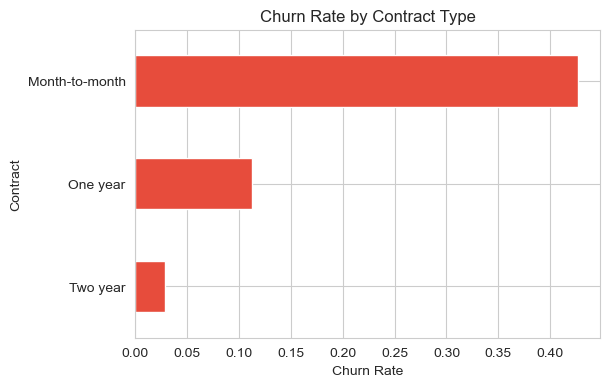

In [6]:
plt.figure(figsize=(6,4))
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean())
contract_churn.sort_values().plot(kind='barh', color='#e74c3c')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Churn Rate')
plt.show()

## Data Cleaning & Feature Engineering

In [8]:
df_model = df.drop('customerID', axis=1)
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

cat_cols = df_model.select_dtypes(include='object').columns.tolist()
df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)
df_encoded.shape

(7043, 31)

In [9]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

## Model Training & Comparison

In [10]:
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42), X_train_scaled, X_test_scaled),
    'Random Forest':       (RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42), X_train, X_test),
    'Gradient Boosting':   (GradientBoostingClassifier(n_estimators=150, max_depth=3, random_state=42), X_train, X_test),
}

results = []
fitted_models = {}

for name, (model, xtr, xte) in models.items():
    model.fit(xtr, y_train)
    preds = model.predict(xte)
    proba = model.predict_proba(xte)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, proba)
    })
    fitted_models[name] = (model, xte, preds, proba)

results_df = pd.DataFrame(results).round(3).sort_values('ROC-AUC', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
1,Random Forest,0.806,0.669,0.535,0.594,0.844
0,Logistic Regression,0.806,0.659,0.559,0.605,0.842
2,Gradient Boosting,0.797,0.651,0.508,0.571,0.838


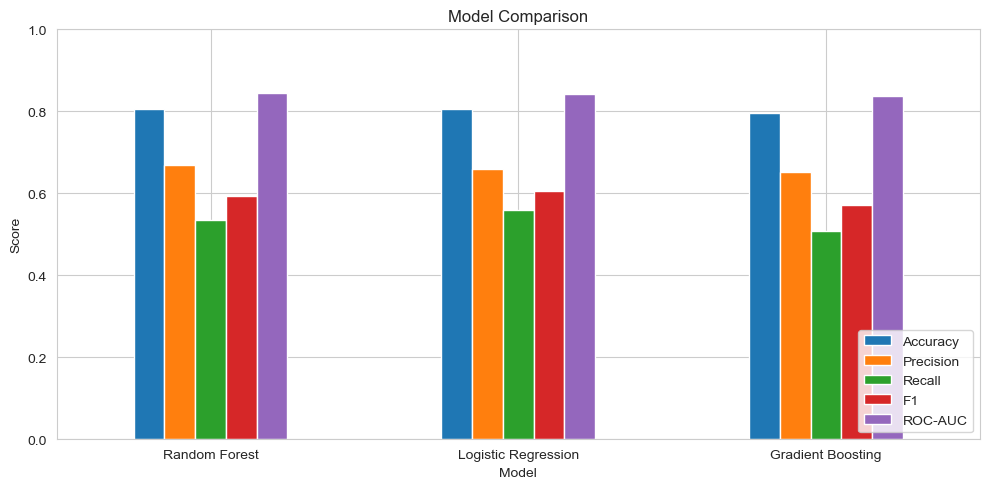

In [11]:
results_df.set_index('Model')[['Accuracy','Precision','Recall','F1','ROC-AUC']].plot(
    kind='bar', figsize=(10,5), ylim=(0,1)
)
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Best Model - Evaluation

Best model: Random Forest


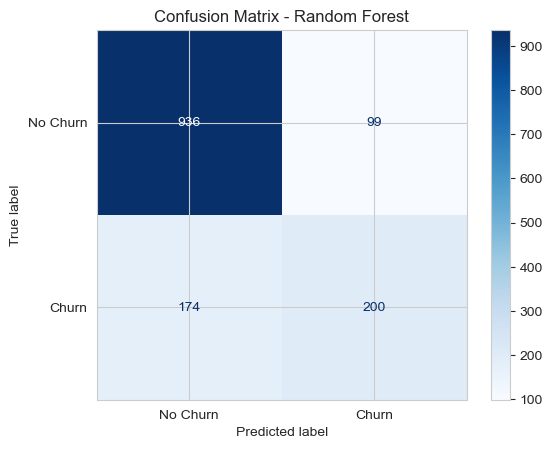

In [12]:
best_name = results_df.iloc[0]['Model']
best_model, best_xte, best_preds, best_proba = fitted_models[best_name]
print("Best model:", best_name)

cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn','Churn'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix - {best_name}')
plt.show()

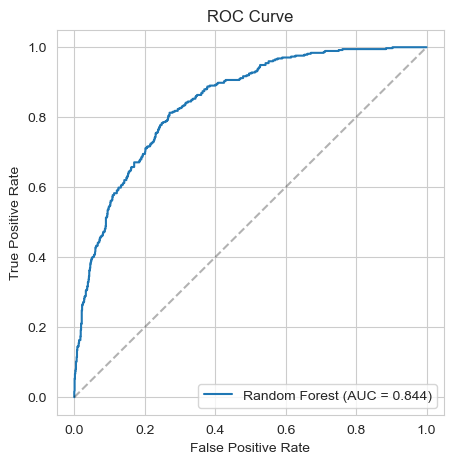

In [13]:
fpr, tpr, _ = roc_curve(y_test, best_proba)
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f'{best_name} (AUC = {roc_auc_score(y_test, best_proba):.3f})')
plt.plot([0,1],[0,1],'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## Feature Importance

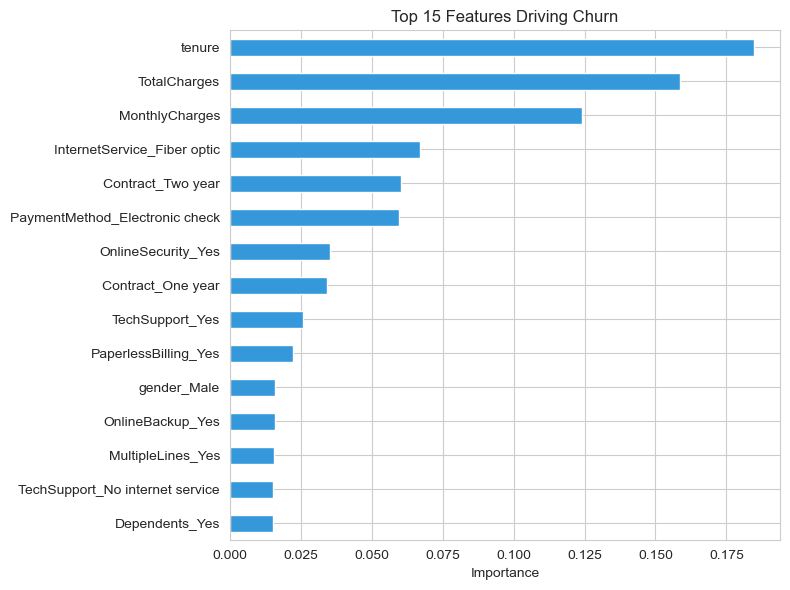

In [15]:
importance_model = fitted_models['Random Forest'][0]
importances = pd.Series(importance_model.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
top_features.sort_values().plot(kind='barh', color='#3498db')
plt.title('Top 15 Features Driving Churn')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Save Model

In [16]:
joblib.dump(best_model, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X_train.columns), 'model_columns.pkl')

print("Saved model:", best_name)
results_df

Saved model: Random Forest


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
1,Random Forest,0.806,0.669,0.535,0.594,0.844
0,Logistic Regression,0.806,0.659,0.559,0.605,0.842
2,Gradient Boosting,0.797,0.651,0.508,0.571,0.838
